<a href="https://colab.research.google.com/github/guslimaa777/45419370/blob/main/aula1_machine_learning_industria_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1 – Machine Learning Aplicada à Indústria
## Notebook do Aluno

**Nome:** _________________gustavo reis lima___________________  
**Data:** _________________05/09/2026___________________  

### Objetivo da aula
- compreender o problema industrial;
- ler a base de dados;
- identificar faltantes, duplicatas e possíveis outliers;
- registrar observações que serão usadas no pré-processamento.


## 1. Importação das bibliotecas

Complete a célula abaixo com as bibliotecas que serão usadas.


In [1]:
# Complete:
# importar pandas
# importar numpy
# importar matplotlib.pyplot como plt
# importar seaborn como sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 2. Leitura da base

Complete com o nome do arquivo e carregue o dataset.


In [6]:
arquivo = '/content/dados_aula1_machine_learning_industria.csv'
df = pd.read_csv(arquivo)
# visualizar dimensões da base
print(f'Dimensões da base: {df.shape}')
df.head()

Dimensões da base: (188, 15)


,timestamp,lote_producao,operador,modo_controle,status_valvula,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3,status_instrumentacao
0,2026-01-10 08:00:00,Lote_A,op_b,automatico,normal,121.44,128.08,3.518,95.00,56.97,2.960,220.8,7.09,1.069,estavel
1,2026-01-10 09:00:00,Lote_D,op_c,cascata,normal,126.17,119.32,4.616,43.34,63.26,2.532,402.1,6.99,1.053,inspecao
2,2026-01-10 10:00:00,Lote_B,op_d,manual,intermitente,128.54,129.11,4.118,40.67,63.14,2.182,284.1,6.72,1.021,inspecao
3,2026-01-10 11:00:00,Lote_C,op_a,automatico,intermitente,106.50,102.68,3.547,43.94,64.75,2.772,486.3,6.67,1.093,inspecao
4,2026-01-10 12:00:00,Lote_C,op_a,automatico,normal,101.59,NaN,4.085,102.00,83.82,3.173,283.3,6.66,1.004,estavel


## 3. Visualização inicial

Mostre as primeiras linhas da base e registre abaixo o que você percebe.

**Anotações do aluno:**  
- ______________________________________________  
- ______________________________________________  
- ______________________________________________


In [7]:
display(df.head())

,timestamp,lote_producao,operador,modo_controle,status_valvula,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3,status_instrumentacao
0,2026-01-10 08:00:00,Lote_A,op_b,automatico,normal,121.44,128.08,3.518,95.00,56.97,2.960,220.8,7.09,1.069,estavel
1,2026-01-10 09:00:00,Lote_D,op_c,cascata,normal,126.17,119.32,4.616,43.34,63.26,2.532,402.1,6.99,1.053,inspecao
2,2026-01-10 10:00:00,Lote_B,op_d,manual,intermitente,128.54,129.11,4.118,40.67,63.14,2.182,284.1,6.72,1.021,inspecao
3,2026-01-10 11:00:00,Lote_C,op_a,automatico,intermitente,106.50,102.68,3.547,43.94,64.75,2.772,486.3,6.67,1.093,inspecao
4,2026-01-10 12:00:00,Lote_C,op_a,automatico,normal,101.59,NaN,4.085,102.00,83.82,3.173,283.3,6.66,1.004,estavel


## 4. Tipos de dados

Verifique os tipos das colunas e descreva quais são numéricas e quais são categóricas.

**Anotações do aluno:**  
- Colunas numéricas: ______________________________________________  
- Colunas categóricas: ____________________________________________  


In [8]:
# Complete para exibir informações gerais da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                188 non-null    object 
 1   lote_producao            188 non-null    object 
 2   operador                 183 non-null    object 
 3   modo_controle            183 non-null    object 
 4   status_valvula           188 non-null    object 
 5   setpoint_vazao_l_min     188 non-null    float64
 6   vazao_medida_l_min       176 non-null    float64
 7   pressao_linha_bar        178 non-null    float64
 8   temperatura_processo_c   178 non-null    float64
 9   abertura_valvula_pct     188 non-null    float64
 10  vibracao_bomba_mm_s      188 non-null    float64
 11  tempo_resposta_ms        177 non-null    float64
 12  ph_produto               180 non-null    float64
 13  densidade_produto_g_cm3  188 non-null    float64
 14  status_instrumentacao    1

## 5. Estatísticas descritivas

Gere estatísticas descritivas das variáveis numéricas.


In [9]:
# Complete
# Gerar estatísticas descritivas para variáveis numéricas
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
setpoint_vazao_l_min,188.0,119.056277,12.164116,90.340,110.3375,119.2300,126.9200,156.950
vazao_medida_l_min,176.0,119.571761,13.808622,90.230,110.2875,118.5650,128.7800,160.330
pressao_linha_bar,178.0,3.954781,0.842332,2.811,3.5655,3.8865,4.1190,10.200
temperatura_processo_c,178.0,43.874213,9.399248,26.070,40.0275,43.1750,46.6650,110.000
abertura_valvula_pct,188.0,58.468617,16.380992,18.010,46.7575,58.6000,67.7500,99.280
vibracao_bomba_mm_s,188.0,2.336059,0.958364,0.386,1.7935,2.2900,2.7210,9.100
tempo_resposta_ms,177.0,337.286441,129.197193,130.100,278.2000,321.4000,377.5000,1500.000
ph_produto,180.0,6.806500,0.312416,6.040,6.6100,6.8200,7.0125,7.560
densidade_produto_g_cm3,188.0,1.040255,0.030946,0.949,1.0210,1.0395,1.0620,1.134


## 6. Valores faltantes

Descubra quantos valores faltantes existem por coluna.

**Pergunta:** quais colunas parecem exigir maior atenção?


In [10]:
# Complete
# Contar valores faltantes por coluna
df.isnull().sum().sort_values(ascending=False)

,0
vazao_medida_l_min,12
tempo_resposta_ms,11
pressao_linha_bar,10
temperatura_processo_c,10
ph_produto,8
modo_controle,5
operador,5
setpoint_vazao_l_min,0
status_valvula,0
timestamp,0


**Resposta do aluno:**  
____________________________________________________________  
____________________________________________________________


## 7. Duplicatas

Verifique se existem linhas duplicadas.


In [11]:
# Complete
df[df.duplicated]

,timestamp,lote_producao,operador,modo_controle,status_valvula,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3,status_instrumentacao
180,2026-01-16 02:00:00,Lote_A,op_b,automatico,normal,126.92,127.07,3.188,47.67,56.22,1.830,NaN,6.89,1.062,estavel
181,2026-01-11 20:00:00,Lote_B,op_b,automatico,normal,104.35,117.10,3.604,41.98,74.36,2.865,NaN,6.94,1.039,inspecao
182,2026-01-17 09:00:00,Lote_A,op_a,automatico,normal,129.25,130.73,4.119,41.68,53.36,2.494,405.6,6.84,0.980,estavel
183,2026-01-16 07:00:00,Lote_A,op_b,automatico,normal,118.13,110.30,3.899,41.80,67.75,3.392,265.0,NaN,1.063,estavel
184,2026-01-15 14:00:00,Lote_B,op_b,manual,normal,112.18,111.88,4.422,47.48,77.64,2.083,308.3,6.87,1.039,estavel
185,2026-01-15 21:00:00,Lote_B,op_c,automatico,travada,106.44,92.76,3.623,40.08,59.22,3.021,226.5,6.78,0.999,inspecao
186,2026-01-14 14:00:00,Lote_A,op_b,automatico,normal,123.25,120.36,3.720,NaN,49.08,3.130,250.3,6.82,0.987,estavel
187,2026-01-11 16:00:00,Lote_A,op_b,automatico,normal,124.61,118.29,4.222,46.32,18.01,2.312,399.4,6.92,1.069,estavel


**Resposta do aluno:**  
Quantidade de duplicatas encontradas: ______________________


## 8. Busca inicial por outliers

Escolha algumas colunas numéricas importantes e gere boxplots.
Sugestão:
- pressao_linha_bar
- temperatura_processo_c
- vibracao_bomba_mm_s
- tempo_resposta_ms


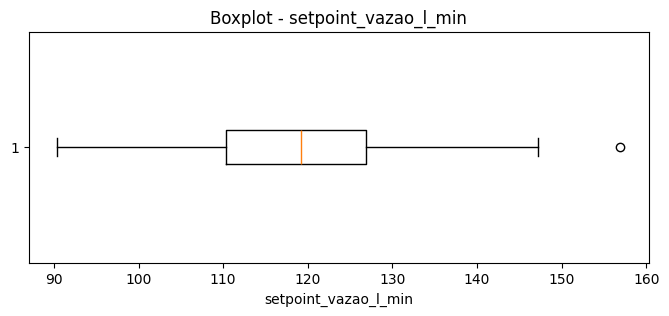

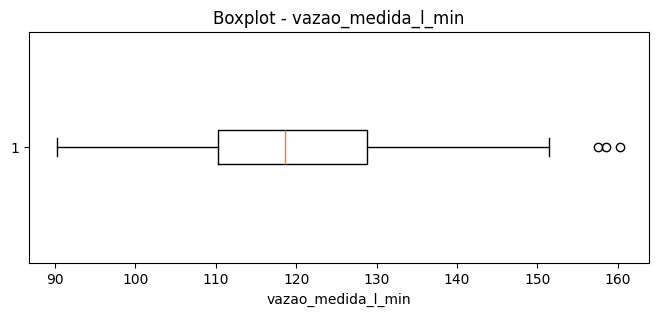

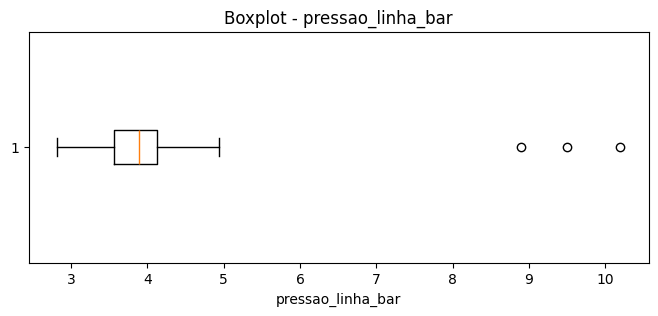

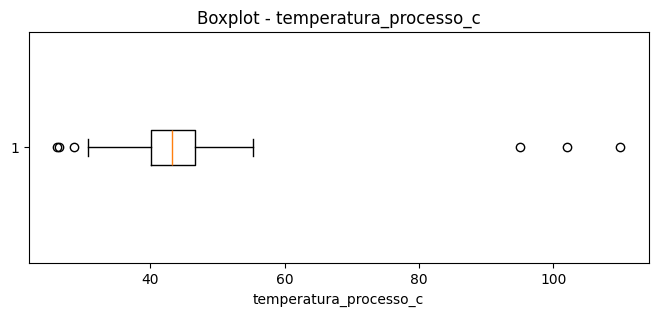

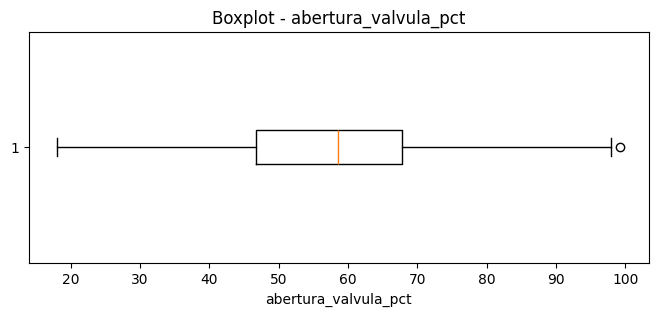

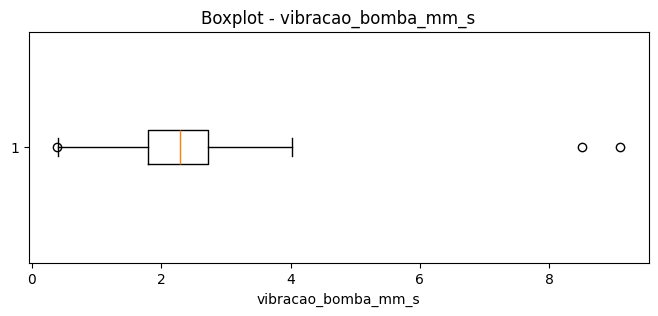

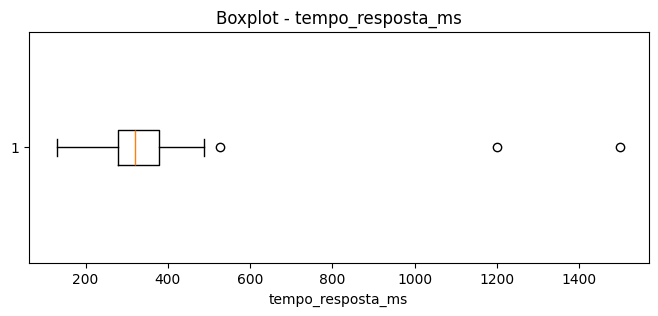

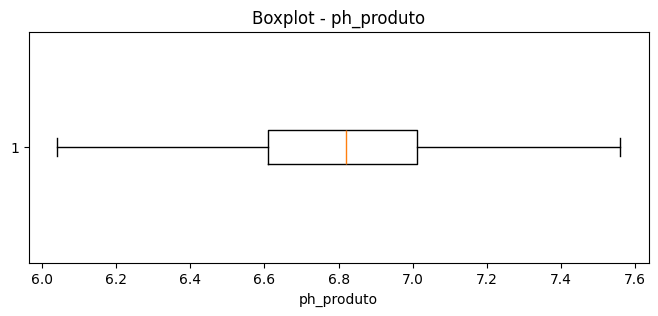

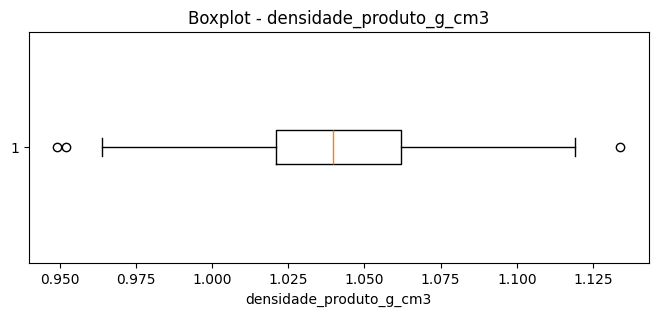

In [12]:
# Complete
# dica: crie uma lista com as colunas e use um laço para gerar os gráficos
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()

for coluna in colunas_numericas:
  plt.figure(figsize=(8 ,3))
  plt.boxplot(df[coluna].dropna(), vert=False)
  plt.title(f'Boxplot - {coluna}')
  plt.xlabel(coluna)
  plt.show()

**Anotações do aluno sobre possíveis outliers:**  
- ______________________________________________  
- ______________________________________________  
- ______________________________________________


## 9. Correlação entre variáveis numéricas

Calcule a matriz de correlação.


In [13]:
# Complete
# Gerar matriz de correlação
df.select_dtypes(include=np.number).corr(numeric_only=True)

,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3
setpoint_vazao_l_min,1.000000,0.801101,-0.091657,0.017862,0.054249,-0.131508,0.043946,0.159991,-0.031027
vazao_medida_l_min,0.801101,1.000000,0.012123,0.089933,0.068041,-0.070068,-0.036759,0.133953,-0.072082
pressao_linha_bar,-0.091657,0.012123,1.000000,-0.040471,-0.031933,-0.004311,-0.034882,-0.033072,0.071375
temperatura_processo_c,0.017862,0.089933,-0.040471,1.000000,-0.002120,0.057550,-0.016420,0.021347,-0.024445
abertura_valvula_pct,0.054249,0.068041,-0.031933,-0.002120,1.000000,-0.093294,-0.025390,-0.005975,-0.054070
vibracao_bomba_mm_s,-0.131508,-0.070068,-0.004311,0.057550,-0.093294,1.000000,-0.064778,-0.078114,-0.101135
tempo_resposta_ms,0.043946,-0.036759,-0.034882,-0.016420,-0.025390,-0.064778,1.000000,0.097510,0.027675
ph_produto,0.159991,0.133953,-0.033072,0.021347,-0.005975,-0.078114,0.097510,1.000000,0.001702
densidade_produto_g_cm3,-0.031027,-0.072082,0.071375,-0.024445,-0.054070,-0.101135,0.027675,0.001702,1.000000


## 10. Criação de uma variável auxiliar

Crie uma variável com o desvio absoluto entre:
- setpoint_vazao_l_min
- vazao_medida_l_min

Nome sugerido: `desvio_vazao_abs`


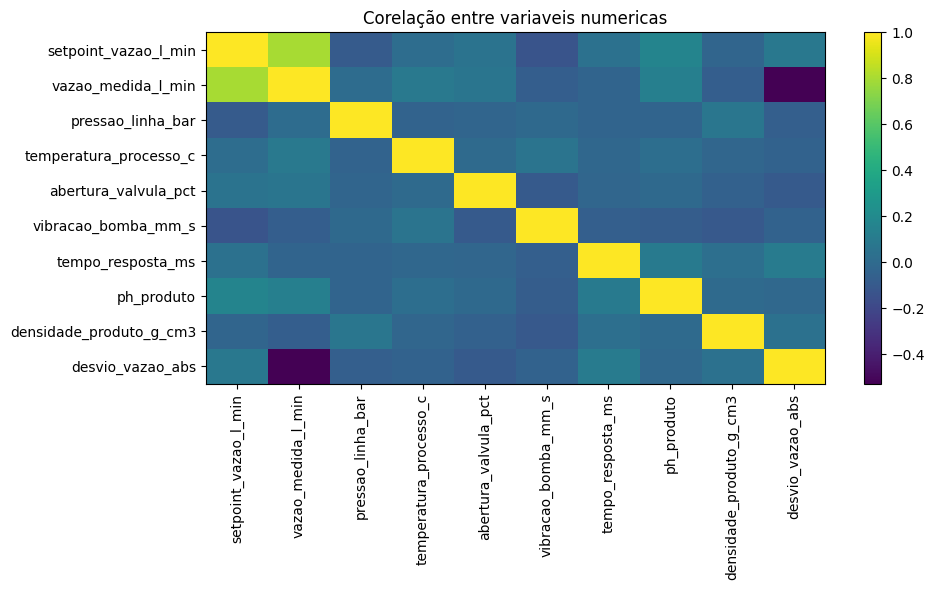

,setpoint_vazao_l_min,vazao_medida_l_min,desvio_vazao_abs
0,121.44,128.08,-6.64
1,126.17,119.32,6.85
2,128.54,129.11,-0.57
3,106.50,102.68,3.82
4,101.59,NaN,NaN


In [14]:
 # Adicionado para garantir que sns esteja definido
desvio_vazao_abs = df['setpoint_vazao_l_min'] - df['vazao_medida_l_min']
df['desvio_vazao_abs'] = desvio_vazao_abs
df.head()

corr = df.select_dtypes(include=[np.number]).corr(numeric_only=True)

plt.figure(figsize=(10, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Corelação entre variaveis numericas')
plt.tight_layout()
plt.show()

df['desvio_vazao_abs'] = df['setpoint_vazao_l_min'] - df['vazao_medida_l_min'].abs()
df[['setpoint_vazao_l_min', 'vazao_medida_l_min', 'desvio_vazao_abs']].head()

## 11. Interpretação técnica

Responda com base na exploração realizada:

1. Quais problemas de qualidade de dados foram identificados?  
Foram identificados possíveis valores ausentes, valores discrepantes (outliers), inconsistências entre registros e variações que podem indicar erros de medição ou falhas na coleta dos dados.

2. Quais variáveis parecem críticas para avaliar a instrumentação?  
As variáveis diretamente relacionadas às medições dos sensores/instrumentos são as mais críticas, especialmente aquelas que apresentam valores anômalos, grande variação, dados ausentes ou comportamento fora do esperado. Essas variáveis ajudam a identificar problemas de calibração, ruído ou falhas de instrumentação.

3. Por que não devemos treinar um modelo imediatamente, sem inspeção?  
Porque o modelo pode aprender padrões incorretos provenientes de erros, ruídos ou vieses dos dados, em vez de aprender o fenômeno real. A inspeção e a validação da qualidade dos dados são necessárias para evitar conclusões erradas e garantir que o modelo seja confiável.


## 12. Fechamento

Nesta aula, você começou a trabalhar o início do pipeline de Machine Learning:
- definição do problema;
- conhecimento da base;
- análise exploratória;
- identificação de problemas de qualidade.

Na próxima etapa, a base poderá ser tratada para uso em modelagem.



In [15]:
resumo = {
    'linhas': df.shape[0],
    'colunas': df.shape[1],
    'duplicatas': int(df.duplicated().sum()),
    'colunas_com_faltantes': int((df.isna().sum() > 0.).sum())
}
print('Resumo da base para fechamento da aula:')
for chave, valor in resumo.items():
    print(f'- {chave}: {valor}')

Resumo da base para fechamento da aula:
- linhas: 188
- colunas: 16
- duplicatas: 8
- colunas_com_faltantes: 8
